In [1]:
from typing import Annotated

from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage

C:\Users\manoj\PycharmProjects\LangGraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()

# Model
model = ChatGoogleGenerativeAI(model='gemini-3-flash-preview')

In [3]:
class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [4]:
def chat_node(state: ChatState):

    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })

    if decision["approved"] == 'no':
        return {"messages": [AIMessage(content="Not approved.")]}

    else:
        response = model.invoke(state["messages"])
        return {"messages": [response]}

In [5]:
# 3. Build the graph: START -> chat -> END
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

In [22]:
# Checkpointer is required for interrupts
checkpointer = MemorySaver()

# Compile the app
app = builder.compile(checkpointer=checkpointer)

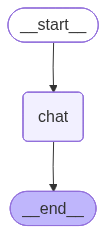

In [7]:
app

In [23]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '1234'}}

# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [
        ("user", "Explain gradient descent in very simple terms.")
    ]
}

# Invoke the graph for the first time
result = app.invoke(input=initial_input, config=config)

In [24]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='7b3c45f0-d545-4260-9182-7397ed322ade')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'Explain gradient descent in very simple terms.', 'instruction': 'Approve this question? yes/no'}, id='8dc6531ad728c8261c8c500228d22808')]}

In [25]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain gradient descent in very simple terms.',
 'instruction': 'Approve this question? yes/no'}

In [26]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n): ")

In [27]:
# Resume the graph with the approval decision
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config,
)

In [29]:
print(final_result["messages"][-1].content[0]['text'])

Imagine you are standing at the very top of a large, grassy mountain. It is a very foggy day, and you can only see about two feet in front of you. Your goal is to get to the very bottom of the valley where there is a lake.

Because you can't see the bottom, you have to use a strategy. **Gradient Descent** is that strategy.

Here is how you do it:

### 1. Feel the slope
Since you can’t see the lake, you use your feet to feel the ground around you. You look for which direction slopes **downward** the most.

### 2. Take a step
Once you find the steepest way down, you take one step in that direction.

### 3. Repeat
After that step, you stop and feel the ground again. You find the new steepest way down and take another step. You keep doing this over and over.

### 4. Reaching the bottom
Eventually, the ground will feel flat in every direction. That means you’ve reached the bottom of the valley (the lake).

***

### In the world of computers, here is what those things mean:

*   **The Mounta